In [7]:
import pandas as pd
import numpy as np
import socket
import struct

# 1. Setup Paths
base_path = r'C:\Users\natna\Downloads\KAIM WEEK-5,6\Improved-detection-of-fraud-cases-for-e-commerce-and-bank-transactions'
fraud_path = f'{base_path}\\data\\raw\\Fraud_Data.csv'
ip_path = f'{base_path}\\data\\raw\\IpAddress_to_Country.csv'

# 2. Load Data
fraud_df = pd.read_csv(fraud_path)
ip_df = pd.read_csv(ip_path)

# 3. Robust Conversion Function
def ip_to_float(ip):
    try:
        if isinstance(ip, (int, float)): return float(ip)
        return float(struct.unpack("!I", socket.inet_aton(str(ip).strip()))[0])
    except:
        return np.nan

# 4. Prepare DataFrames (Ensure numeric and sorted)
fraud_df['ip_address_int'] = fraud_df['ip_address'].apply(ip_to_float)
fraud_df = fraud_df.dropna(subset=['ip_address_int']).sort_values('ip_address_int')

ip_df['lower_bound_ip_address'] = ip_df['lower_bound_ip_address'].astype(float)
ip_df['upper_bound_ip_address'] = ip_df['upper_bound_ip_address'].astype(float)
ip_df = ip_df.sort_values('lower_bound_ip_address')

# 5. Perform the Merge
# We use direction='backward' to find the largest lower_bound <= ip_address_int
merged_df = pd.merge_asof(
    fraud_df, 
    ip_df, 
    left_on='ip_address_int', 
    right_on='lower_bound_ip_address',
    direction='backward'
)

# 6. Validate Country Mapping
# Check if the IP actually falls within the upper bound of the matched range
merged_df['country'] = np.where(
    (merged_df['ip_address_int'] <= merged_df['upper_bound_ip_address']),
    merged_df['country'],
    'Unknown'
)

# 7. Feature Engineering
merged_df['signup_time'] = pd.to_datetime(merged_df['signup_time'])
merged_df['purchase_time'] = pd.to_datetime(merged_df['purchase_time'])

merged_df['hour_of_day'] = merged_df['purchase_time'].dt.hour
merged_df['day_of_week'] = merged_df['purchase_time'].dt.dayofweek
merged_df['time_since_signup'] = (merged_df['purchase_time'] - merged_df['signup_time']).dt.total_seconds()

# 8. Save
output_file = f'{base_path}\\data\\processed\\fraud_data_final.csv'
merged_df.to_csv(output_file, index=False)

print(f"SUCCESS: Task 1 Completed!")
print(f"Total records in final file: {len(merged_df)}")
print(f"Sample Countries found: {merged_df['country'].unique()[:5]}")

SUCCESS: Task 1 Completed!
Total records in final file: 151112
Sample Countries found: ['Unknown' 'Australia' 'Thailand' 'China' 'Japan']


C:\Users\natna\AppData\Local\Temp\ipykernel_23976\2889029355.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')


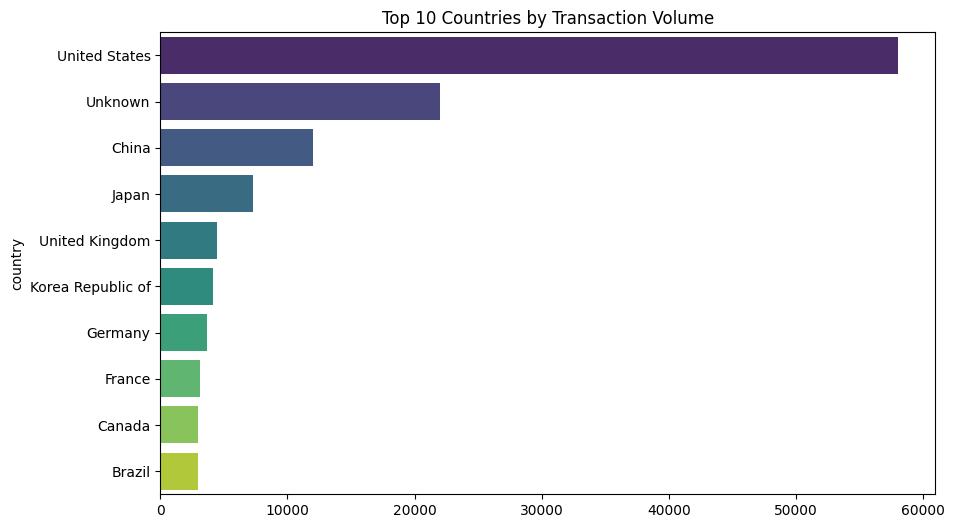

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 10 countries by number of transactions
top_countries = merged_df['country'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 10 Countries by Transaction Volume')
plt.show()

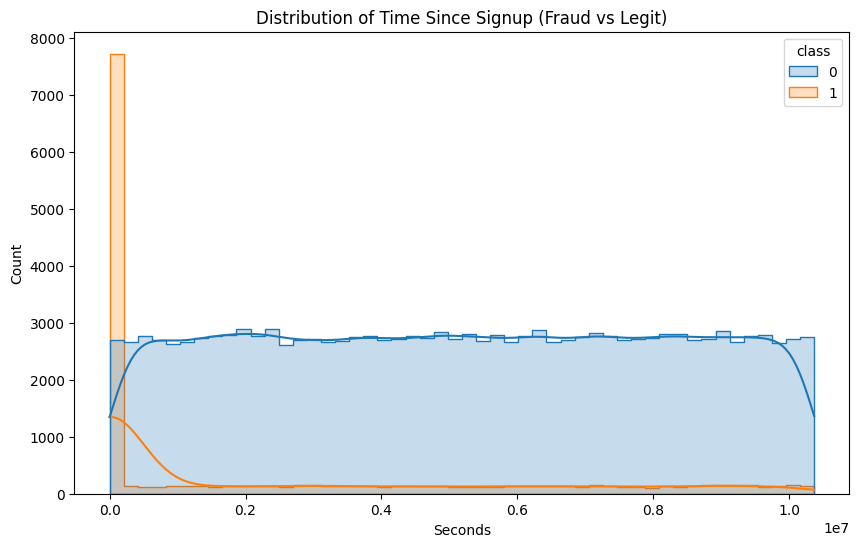

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(data=merged_df, x='time_since_signup', hue='class', bins=50, kde=True, element="step")
plt.title('Distribution of Time Since Signup (Fraud vs Legit)')
plt.xlabel('Seconds')
plt.show()

In [12]:
fraud_ratio = merged_df['class'].value_counts(normalize=True) * 100
print(f"Class 0 (Legit): {fraud_ratio[0]:.2f}%")
print(f"Class 1 (Fraud): {fraud_ratio[1]:.2f}%")

Class 0 (Legit): 90.64%
Class 1 (Fraud): 9.36%


In [4]:
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from collections import Counter

# --- STEP 1: LOAD DATA ---
fraud_df = pd.read_csv('../data/raw/Fraud_Data.csv')
ip_df = pd.read_csv('../data/raw/IpAddress_to_Country.csv')

# --- STEP 2: GEOLOCATION MERGING (Task 1.1) ---
# Ensure IP addresses are numeric for merging
fraud_df['ip_address'] = fraud_df['ip_address'].astype(float)
ip_df['lower_bound_ip_address'] = ip_df['lower_bound_ip_address'].astype(float)
ip_df['upper_bound_ip_address'] = ip_df['upper_bound_ip_address'].astype(float)

# Sort for merge_asof
fraud_df = fraud_df.sort_values('ip_address')
ip_df = ip_df.sort_values('lower_bound_ip_address')

# Merge to find the country
df_merged = pd.merge_asof(
    fraud_df, ip_df, 
    left_on='ip_address', 
    right_on='lower_bound_ip_address'
)

# Validate the merge: if IP is within the range, keep country; else 'Unknown'
df_merged['country'] = np.where(
    (df_merged['ip_address'] >= df_merged['lower_bound_ip_address']) & 
    (df_merged['ip_address'] <= df_merged['upper_bound_ip_address']),
    df_merged['country'], 
    'Unknown'
)

# Drop redundant IP range columns
df_merged = df_merged.drop(columns=['lower_bound_ip_address', 'upper_bound_ip_address'])

# --- STEP 3: FEATURE ENGINEERING (Task 1.2 - 1.4) ---
# Convert to datetime
df_merged['signup_time'] = pd.to_datetime(df_merged['signup_time'])
df_merged['purchase_time'] = pd.to_datetime(df_merged['purchase_time'])

# New Feature: Time to Purchase (in seconds)
df_merged['time_to_purchase'] = (df_merged['purchase_time'] - df_merged['signup_time']).dt.total_seconds()

# New Features: Hour and Day of Week
df_merged['purchase_hour'] = df_merged['purchase_time'].dt.hour
df_merged['purchase_day'] = df_merged['purchase_time'].dt.dayofweek

# --- STEP 4: ENCODING CATEGORICAL VARIABLES (Task 1.5 - THE FIX) ---
# This step converts 'Ads', 'Chrome', etc., into 0s and 1s so SMOTE works.
categorical_cols = ['source', 'browser', 'sex']

# One-hot encoding
df_final = pd.get_dummies(df_merged, columns=categorical_cols, drop_first=True)

# Note: 'country' has 180+ values. To prevent a "column explosion," we drop it 
# for this baseline, or you can use Frequency Encoding.
X = df_final.drop(columns=[
    'class', 'user_id', 'device_id', 'signup_time', 
    'purchase_time', 'ip_address', 'country'
])
y = df_final['class']

# --- STEP 5: TRAIN-TEST SPLIT ---
# Always split BEFORE resampling to keep the test set "real-world"
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- STEP 6: HANDLE CLASS IMBALANCE (Task 1.6) ---
print(f"Distribution BEFORE SMOTE: {Counter(y_train)}")

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Distribution AFTER SMOTE: {Counter(y_train_resampled)}")

# --- STEP 7: SAVE PROCESSED DATA ---
X_train_resampled.to_csv('../data/processed/X_train_resampled.csv', index=False)
pd.Series(y_train_resampled).to_csv('../data/processed/y_train_resampled.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

print("Files saved to data/processed/. You are ready for Modeling!")

Distribution BEFORE SMOTE: Counter({0: 109568, 1: 11321})
Distribution AFTER SMOTE: Counter({0: 109568, 1: 109568})
Files saved to data/processed/. You are ready for Modeling!
